In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import pandas as pd

In [3]:
# read in state level external data
prev_year_state_margins = pd.read_csv("https://raw.githubusercontent.com/ecw70574/US-Census-Voting-and-Registration-DSCI-Capstone-Project/refs/heads/main/prev_year_state_margins.csv")
stateecon_indicators = pd.read_csv("https://raw.githubusercontent.com/ecw70574/US-Census-Voting-and-Registration-DSCI-Capstone-Project/refs/heads/main/stateecon_indicators.csv")


In [4]:
stateecon_indicators

,state,year,oct_unemp,nov_unemp,percapita_personalincome
0,AL,10,10.1,10.1,33848
1,AL,12,7.8,7.8,35559
2,AL,14,6.4,6.3,36722
3,AL,18,3.8,3.8,41324
4,AL,20,5.2,4.8,45843
...,...,...,...,...,...
324,WY,14,4.3,4.2,56251
325,WY,18,4.0,4.0,59197
326,WY,20,5.6,5.5,65094
327,WY,22,3.5,3.4,76394


In [5]:
# need to make unemployment a proportion
stateecon_indicators["oct_unemp"] = stateecon_indicators["oct_unemp"] / 100
stateecon_indicators["nov_unemp"] = stateecon_indicators["nov_unemp"] / 100


In [6]:
# read in and append the agg census data
import pandas as pd
import numpy as np
all_years = pd.DataFrame()
for i in range(10,26,2):
  # read in file
  filename = "panel_" + str(i) + ".csv"
  this_df = pd.read_csv("https://raw.githubusercontent.com/ecw70574/US-Census-Voting-and-Registration-DSCI-Capstone-Project/refs/heads/main/processed/" + filename)
  all_years = pd.concat([this_df, all_years])
all_years.head()


,states_encoded,sex,age_group,race_grouped,year,weight,did_vote,education_group_associates,education_group_bachelors,education_group_graduate,...,inflation_pct,unemployment_pct,approval_rating_pct,lag_popular_vote_pct,lag_electoral_votes,time_at_curr_address_-9,time_at_curr_address_-3,time_at_curr_address_-2,time_at_curr_address_5,time_at_curr_address_6
0,AK,1,18-24,american_indian,24,58646740.0,0.137642,0.0,0.0,0.0,...,3.4,3.9,45.0,51.3,538.0,NaN,NaN,NaN,NaN,NaN
1,AK,1,18-24,asian,24,9977498.0,0.514243,0.0,0.0,0.0,...,3.4,3.9,45.0,51.3,538.0,NaN,NaN,NaN,NaN,NaN
2,AK,1,18-24,black,24,5640824.0,1.000000,0.0,0.0,0.0,...,3.4,3.9,45.0,51.3,538.0,NaN,NaN,NaN,NaN,NaN
3,AK,1,18-24,multiracial,24,9671812.0,1.000000,0.0,0.0,0.0,...,3.4,3.9,45.0,51.3,538.0,NaN,NaN,NaN,NaN,NaN
4,AK,1,18-24,pacific_islander,24,9186457.0,1.000000,0.0,0.0,0.0,...,3.4,3.9,45.0,51.3,538.0,NaN,NaN,NaN,NaN,NaN


In [7]:
# rename state column for consistency
all_years = all_years.rename(columns={"states_encoded": "state"})

In [8]:
all_years["year"].value_counts()

,count
year,
24,3600
22,3600
20,3600
18,3600
16,3600
14,3600
12,3600
10,3600


In [9]:
# Merge all state/year level datasets
from sklearn.preprocessing import MinMaxScaler
merge1 = pd.merge(all_years, prev_year_state_margins, on=["year","state"], how='left')
merge2 = pd.merge(merge1, stateecon_indicators, on=["year","state"], how='left')

# Normalize all to 0-1
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler()

# Normalize non-percentage/proportion columns
cols_to_scale = ["percapita_personalincome", 'lag_popular_vote_pct', 'approval_rating_pct', 'gdp_growth_pct', 'inflation_pct', 'unemployment_pct']
all_normalized = merge2.copy()

all_normalized[cols_to_scale] = min_max_scaler.fit_transform(
    merge2[cols_to_scale]
)

In [10]:
all_normalized["sex"].value_counts()

,count
sex,
1,14400
2,14400


In [11]:
year_turnout = (
    all_normalized
    .groupby("year")
    .apply(lambda g: (g["did_vote"] * g["weight"]).sum() / g["weight"].sum())
    .reset_index(name="weighted_turnout")
)


/tmp/ipykernel_22104/4292423006.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["did_vote"] * g["weight"]).sum() / g["weight"].sum())


In [208]:
year_turnout

,year,weighted_turnout
0,10,0.551747
1,12,0.717492
2,14,0.509611
3,16,0.727067
4,18,0.660278
5,20,0.799951
6,22,0.635882
7,24,0.769463


Text(0, 0.5, 'Weighted Turnout')

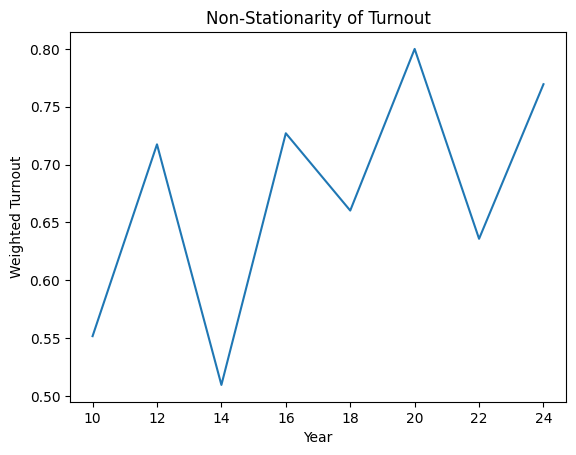

In [12]:
import matplotlib.pyplot as plt
plt.plot(year_turnout["year"],year_turnout["weighted_turnout"])
plt.title('Non-Stationarity of Turnout')
plt.xlabel("Year")
plt.ylabel("Weighted Turnout")

In [13]:
all_normalized.describe()

,sex,year,weight,did_vote,education_group_associates,education_group_bachelors,education_group_graduate,education_group_hs_grad,education_group_less_hs,education_group_some_college,...,lag_electoral_votes,time_at_curr_address_-9,time_at_curr_address_-3,time_at_curr_address_-2,time_at_curr_address_5,time_at_curr_address_6,margin_of_victory_prev,oct_unemp,nov_unemp,percapita_personalincome
count,28800.000000,28800.000000,2.880000e+04,28800.000000,28800.000000,28800.000000,28800.000000,28800.000000,28800.000000,28800.000000,...,10800.000000,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,14400.000000,23688.000000,23688.000000,23688.000000
mean,1.500000,17.000000,5.195583e+08,0.397211,0.067240,0.127108,0.071118,0.195642,0.066147,0.136808,...,535.666667,0.001476,0.005038,0.004400,0.083449,0.347280,0.170329,0.054748,0.054176,0.346707
std,0.500009,4.582655,1.419967e+09,0.395324,0.160883,0.222381,0.169013,0.274554,0.168975,0.235364,...,3.299984,0.023122,0.043248,0.042641,0.178162,0.376978,0.108620,0.023005,0.022652,0.208532
min,1.000000,10.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,531.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001334,0.019000,0.019000,0.000000
25%,1.000000,13.500000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,531.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.088719,0.037000,0.037000,0.176334
50%,1.500000,17.000000,3.383552e+07,0.375042,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,538.000000,0.000000,0.000000,0.000000,0.000000,0.238127,0.160728,0.049000,0.048000,0.319350
75%,2.000000,20.500000,2.729693e+08,0.762023,0.083081,0.204260,0.079093,0.325455,0.054096,0.192738,...,538.000000,0.000000,0.000000,0.000000,0.103932,0.687761,0.250707,0.070000,0.069000,0.482502
max,2.000000,24.000000,2.050646e+10,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,538.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.480409,0.134000,0.134000,1.000000


In [14]:
data = all_normalized

In [15]:
import pandas as pd
import numpy as np
#from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.preprocessing.sequence import pad_sequences

# revised methodology: avoids leakage from same group over time

# 1. load data
# reading in resulting CSV from aggregate_and_build.py script
# data = pd.read_csv("lstm_preprocessed_data.csv")
# data = pd.read_csv("processed/all_years_aggregated.csv")
# data = pd.read_csv("all_years_aggregated.csv")

In [16]:

# 2. group id
data["group_id"] = (
    data["state"].astype(str) + "_" +
    data["sex"].astype(str) + "_" +
    data["age_group"].astype(str) + "_" +
    data["race_grouped"].astype(str)
)

# adding lag and interaction terms

# 3. survival filter
group_survival = (
    data.groupby("group_id")["year"]
    .nunique()
    .reset_index(name='year_count')
)

group_survival.sort_values(by='year_count', ascending=False).head(50)


,group_id,year_count
3599,WY_2_65+_white,8
0,AK_1_18-24_american_indian,8
1,AK_1_18-24_asian,8
2,AK_1_18-24_black,8
3,AK_1_18-24_multiracial,8
4,AK_1_18-24_pacific_islander,8
5,AK_1_18-24_white,8
6,AK_1_25-34_american_indian,8
7,AK_1_25-34_asian,8
8,AK_1_25-34_black,8


In [17]:
# making sure groups are consistent between all 8 years
# true time series will track same groups over time
surviving_groups = group_survival[group_survival["year_count"] >= 8]["group_id"]

model_data = data[data["group_id"].isin(surviving_groups)].copy()

# 4. sort
model_data = model_data.sort_values(["group_id", "year"])

# 5. fill missing
model_data = model_data.fillna(0)

In [18]:
model_data.head()

,state,sex,age_group,race_grouped,year,weight,did_vote,education_group_associates,education_group_bachelors,education_group_graduate,...,time_at_curr_address_-9,time_at_curr_address_-3,time_at_curr_address_-2,time_at_curr_address_5,time_at_curr_address_6,margin_of_victory_prev,oct_unemp,nov_unemp,percapita_personalincome,group_id
25200,AK,1,18-24,american_indian,10,15119989.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.514014,0.000000,0.079,0.079,0.283886,AK_1_18-24_american_indian
21600,AK,1,18-24,american_indian,12,39995614.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.236249,0.215351,0.070,0.070,0.345149,AK_1_18-24_american_indian
18000,AK,1,18-24,american_indian,14,87015677.0,0.133895,0.075103,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.066,0.064,0.373514,AK_1_18-24_american_indian
14400,AK,1,18-24,american_indian,16,56868212.0,0.535432,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.139889,0.000,0.000,0.000000,AK_1_18-24_american_indian
10800,AK,1,18-24,american_indian,18,49817794.0,0.335075,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.060,0.060,0.436422,AK_1_18-24_american_indian


In [19]:
model_data["weight"]

,weight
25200,15119989.0
21600,39995614.0
18000,87015677.0
14400,56868212.0
10800,49817794.0
...,...
17999,372272818.0
14399,404810439.0
10799,432971503.0
7199,516504058.0


In [20]:
# drop weights now that we are done with them?
model_data = model_data.drop(columns=["weight"])

In [218]:
# QUICKLY FIT XGBOOST BASELINE
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
copy = model_data
# copy = copy.drop(columns=["age_group", "sex","race_grouped", "state"])
copy = pd.get_dummies(copy, columns=['age_group', 'sex',"race_grouped","state"],drop_first=True)

# copy['group_num'] = pd.factorize(copy['group_id'])[0] # try to keep group id flag
copy = copy.drop(columns="group_id") # drop original


# sequential split for XGBoost
train_data = copy[copy["year"] <= 18] # for training
val_data   = copy[(copy["year"] > 18) & (copy["year"] <= 22)] # for tuning/selection
# after final model has been tuned/optimized, avoid data leakage
test_data  = copy[copy["year"] == 24] # for testing performance on unseen observations

# after subset, remove years
train_data = train_data.drop(columns="year")
val_data = val_data.drop(columns="year")
test_data = test_data.drop(columns="year")


y_train_xg = train_data["did_vote"]

X_train_xg = train_data.drop(columns="did_vote")
# store weights in an array
# weights = X_train_xg["weight"]
y_val_xg = val_data["did_vote"]
X_val_xg = val_data.drop(columns="did_vote")
y_test_xg = test_data["did_vote"]
X_test_xg = test_data.drop(columns="did_vote")

# Initialize the model
model = XGBRegressor(n_estimators=100, learning_rate=0.1)

# Fit with evaluation
model.fit(X_train_xg, y_train_xg)

# Predict + evaluate
y_pred = model.predict(X_val_xg)

score = model.score(X_val_xg, y_val_xg)  # Returns R^2 score

# TRY XGBOOST with time dependencies / lag

In [219]:
score # RSQ

0.5598299829418136

In [220]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_val_xg, y_pred)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 0.17750179607886632


In [221]:
# on avg 18.4% off (MAE)
# split into train/test/val by years

# less extreme of conservative predictions

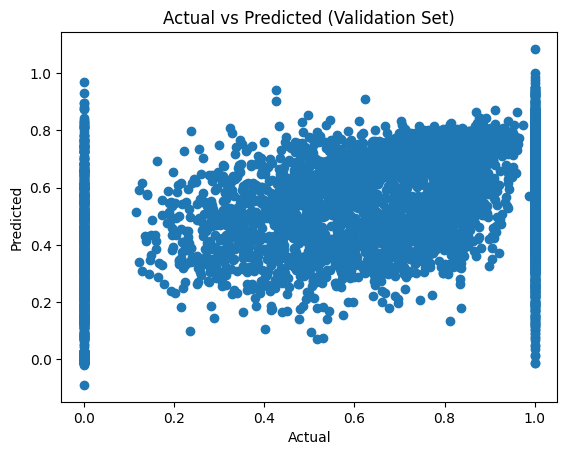

In [222]:
import matplotlib.pyplot as plt
plt.scatter(y_val_xg, y_pred)
plt.title("Actual vs Predicted (Validation Set)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

<Figure size 1000x600 with 0 Axes>

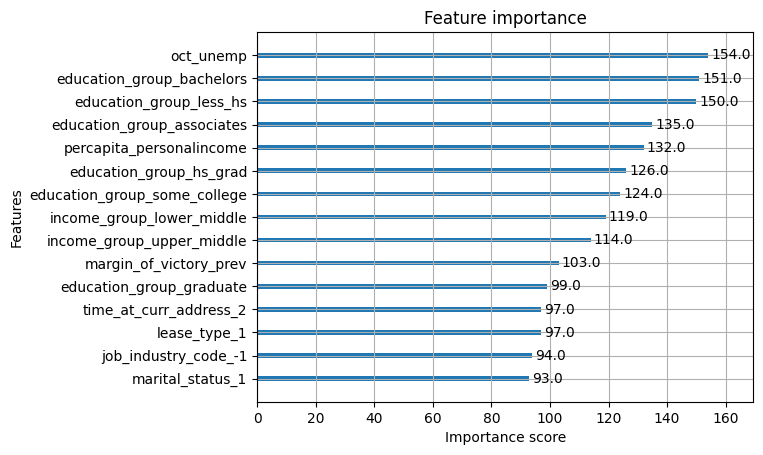

In [223]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_importance(model, max_num_features=15)
plt.show()

In [224]:
# BACK TO LSTM

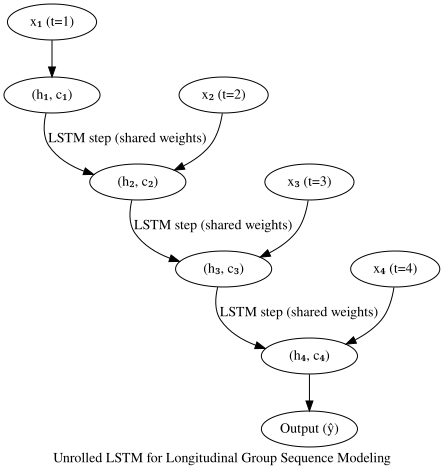

In [252]:
from graphviz import Digraph

dot = Digraph()

# =========================
# Inputs (same group over time)
# =========================
dot.node("x1", "x₁ (t=1)")
dot.node("x2", "x₂ (t=2)")
dot.node("x3", "x₃ (t=3)")
dot.node("x4", "x₄ (t=4)")

# =========================
# LSTM states (paired: hidden + cell)
# =========================
dot.node("s1", "(h₁, c₁)")
dot.node("s2", "(h₂, c₂)")
dot.node("s3", "(h₃, c₃)")
dot.node("s4", "(h₄, c₄)")

# =========================
# Output
# =========================
dot.node("y", "Output (ŷ)")

# =========================
# Input → state transitions
# =========================
dot.edge("x1", "s1")
dot.edge("x2", "s2")
dot.edge("x3", "s3")
dot.edge("x4", "s4")

# =========================
# Recurrent LSTM transitions
# =========================
dot.edge("s1", "s2", label="LSTM step (shared weights)")
dot.edge("s2", "s3", label="LSTM step (shared weights)")
dot.edge("s3", "s4", label="LSTM step (shared weights)")

# =========================
# Final prediction
# =========================
dot.attr(label='Unrolled LSTM for Longitudinal Group Sequence Modeling')
dot.edge("s4", "y")

dot

In [ ]:
'''
train_years = 18
val_years   = 22
test_years  = 24
def build_sequences(df, max_year):
    X_seq, y_seq = [], []

    for gid, g in df.groupby("group_id"):
        g = g.sort_values("year")

        g = g[g["year"] <= max_year]   # filter to find rows in corrct year

        if len(g) < 2:
            continue

        X_seq.append(g[feature_cols].values) # only rows with correct year added to sequence
        y_seq.append(g["did_vote"].values[-1]) # only rows with coreect year added to sequence

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)


X_train, y_train = build_sequences(model_data, 18)
X_val, y_val     = build_sequences(model_data, 22)
X_test, y_test   = build_sequences(model_data, 24)

'''


In [21]:
# remove columns we already grouped on - don't need them as features! - redundant
# also werent properly encoded so were causing typecast errors
model_data = model_data.drop(columns=["age_group", "sex","race_grouped", "state"])


# 6. features
# everything except the group id, year, and target variable
feature_cols = [
    c for c in model_data.columns
    if c not in ["group_id", "year", "did_vote"]
]
# 7. buidling sequences for each group
# need to filter for years then build sequences after

def build_fixed_windows(df, window_size, max_year):
    X_seq, y_seq = [], []

    for gid, g in df.groupby("group_id"):
        g = g.sort_values("year")
        # g = g[g["year"] <= max_year]

        X = g[feature_cols].values
        y = g["did_vote"].values

        for i in range(len(g) - window_size):
            X_seq.append(X[i:i+window_size])
            y_seq.append(y[i + window_size])  # next timestep

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)
window_size = 4

X_train, y_train = build_fixed_windows(model_data, window_size, max_year=18)
X_val, y_val     = build_fixed_windows(model_data, window_size, max_year=22)
X_test, y_test   = build_fixed_windows(model_data, window_size, max_year=24)
'''
# THIS IS INVALID BECAUSE HAS LEAKAGE
# split into training and testing
# this is year level split
# each year snapshot would either be in train, test, or validation set
# train on years <- 2018, validate on 2020-2022, test on 2024
train_data = model_data[model_data["year"] <= 18] # for training
val_data   = model_data[(model_data["year"] > 18) & (model_data["year"] <= 22)] # for tuning/selection
# after final model has been tuned/optimized, avoid data leakage
test_data  = model_data[model_data["year"] == 24] # for testing performance on unseen observations
'''

'\n# THIS IS INVALID BECAUSE HAS LEAKAGE\n# split into training and testing\n# this is year level split\n# each year snapshot would either be in train, test, or validation set\n# train on years <- 2018, validate on 2020-2022, test on 2024\ntrain_data = model_data[model_data["year"] <= 18] # for training\nval_data   = model_data[(model_data["year"] > 18) & (model_data["year"] <= 22)] # for tuning/selection\n# after final model has been tuned/optimized, avoid data leakage\ntest_data  = model_data[model_data["year"] == 24] # for testing performance on unseen observations\n'

In [226]:
X_train.shape

(14400, 4, 73)

In [227]:
X_val.shape

(14400, 4, 73)

In [228]:
X_test.shape

(14400, 4, 73)

In [234]:
model_data[model_data["year"] == 18].head()

,year,did_vote,education_group_associates,education_group_bachelors,education_group_graduate,education_group_hs_grad,education_group_less_hs,education_group_some_college,income_group_high,income_group_low,...,time_at_curr_address_-9,time_at_curr_address_-3,time_at_curr_address_-2,time_at_curr_address_5,time_at_curr_address_6,margin_of_victory_prev,oct_unemp,nov_unemp,percapita_personalincome,group_id
10800,18,0.335075,0.0,0.0,0.0,0.619947,0.380053,0.000000,0.0,0.199928,...,0.0,0.0,0.0,0.0,0.0,0.0,0.06,0.06,0.436422,AK_1_18-24_american_indian
10801,18,0.641548,0.0,0.0,0.0,0.358452,0.000000,0.641548,0.0,0.358452,...,0.0,0.0,0.0,0.0,0.0,0.0,0.06,0.06,0.436422,AK_1_18-24_asian
10802,18,0.000000,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.0,0.417978,...,0.0,0.0,0.0,0.0,0.0,0.0,0.06,0.06,0.436422,AK_1_18-24_black
10803,18,0.382555,0.0,0.0,0.0,0.385520,0.266070,0.348410,0.0,0.232159,...,0.0,0.0,0.0,0.0,0.0,0.0,0.06,0.06,0.436422,AK_1_18-24_multiracial
10804,18,0.000000,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.06,0.06,0.436422,AK_1_18-24_pacific_islander


In [ ]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 9.6 MB/s  0:00:0036m-:--:--


In [32]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

# Define input parameters
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]
# set up the architecture - subject to change
model = Sequential([
    # Input layer with input_shape matching your sequences
    LSTM(64, input_shape=(n_timesteps, n_features), return_sequences=False),

    # Optional: Add Dropout to prevent overfitting
    Dropout(0.2),

    # Output layer: 1 for single-value prediction, or len(y_train[0]) for multi-step
    Dense(1, activation='sigmoid')  # Sigmoid to bound 0-1
])

model.compile(optimizer='adam', loss='mse', metrics=["mae"])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [236]:
type(X_train)

numpy.ndarray

In [237]:
type(y_train)

numpy.ndarray

In [ ]:
X_train.shape

(3600, 5, 73)

In [238]:
X_train.shape[1] == 8

False

In [239]:
print(X_train.dtype)
print(type(X_train[0][0][0]))

float32
<class 'numpy.float32'>


In [240]:
print(X_train.dtype)
print(type(X_train[0]))

float32
<class 'numpy.ndarray'>


In [241]:
# Train the model
# history = model.fit(X_train, y_train, epochs=20, batch_size=256, verbose=1)

In [ ]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,           # Wait 5 epochs for improvement
    restore_best_weights=True # Revert to the best model
)

# Use in model.fit
history = model.fit(
    X_train, y_train,
    epochs=100,           # Set a high max, let early stopping take over
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose = 1
)


Epoch 1/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1251 - mae: 0.2882 - val_loss: 0.1139 - val_mae: 0.2652
Epoch 2/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1155 - mae: 0.2642 - val_loss: 0.1124 - val_mae: 0.2580
Epoch 3/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1142 - mae: 0.2613 - val_loss: 0.1116 - val_mae: 0.2618
Epoch 4/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1128 - mae: 0.2588 - val_loss: 0.1100 - val_mae: 0.2535
Epoch 5/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1114 - mae: 0.2563 - val_loss: 0.1093 - val_mae: 0.2548
Epoch 6/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1105 - mae: 0.2550 - val_loss: 0.1079 - val_mae: 0.2522
Epoch 7/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1092 - mae: 0.2528 - val_loss: 0.1073 - val_mae: 0.2518
Epoch 8/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1083 - mae: 0.2512 - val_loss: 0.1055 - val_mae: 0.2465
Epoch 9/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/

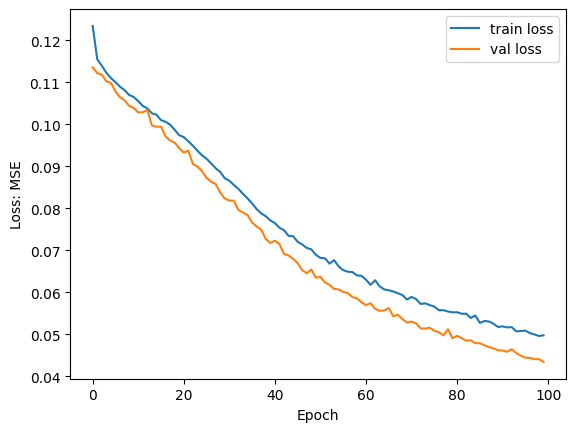

In [24]:
import matplotlib.pyplot as plt
# plot over time
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss: MSE')
plt.show()

In [25]:
val_loss, val_mae = model.evaluate(X_val, y_val)
print("Validation Loss:", val_loss)
print("Validation MAE:", val_mae)

450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0434 - mae: 0.1270
Validation Loss: 0.04338474199175835
Validation MAE: 0.1269768327474594


In [26]:
# performance on training as baseline for testing underfitting
y_pred_train = model.predict(X_train)

450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [27]:
y_pred = model.predict(X_val)

450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [28]:
y_pred = y_pred.flatten()
y_true = y_val.flatten()

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 0.12697677314281464
MSE: 0.04338473826646805
RMSE: 0.2082900340065939


In [30]:
from sklearn.metrics import r2_score

r2 = r2_score(y_true, y_pred)
print("R²:", r2)

R²: 0.735501766204834


In [256]:
# Training rsq
r2 = r2_score(y_train.flatten(), y_pred_train)
print("R²:", r2)

R²: 0.8103890419006348


In [250]:
y_train

array([0.33507454, 0.        , 0.4383479 , ..., 0.85942864, 0.74857175,
       0.86615705], dtype=float32)

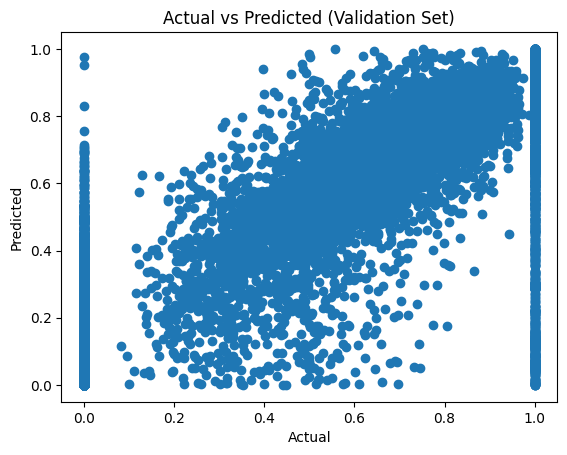

In [251]:
import matplotlib.pyplot as plt
plt.scatter(y_true, y_pred)
plt.title("Actual vs Predicted (Validation Set)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [ ]:
!pip install -U scikeras scikit-learn

In [ ]:
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV, PredefinedSplit

# -----------------------------
# 1. Model definition
# -----------------------------
def create_lstm_model(units=64, dropout_rate=0.2, activation='sigmoid'):

    model = Sequential([
        LSTM(units, input_shape=(n_timesteps, n_features)),
        Dropout(dropout_rate),
        Dense(1, activation=activation)
    ])

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


# -----------------------------
# 2. Wrap model for sklearn
# -----------------------------
model = KerasRegressor(
    model=create_lstm_model,
    verbose=0
)


# -----------------------------
# 3. (IMPORTANT) Handle tanh correctly
# -----------------------------
# If you include tanh, you MUST rescale y

use_tanh = False  # switch this if you want to experiment

if use_tanh:
    y_train_gs = (y_train * 2) - 1
    y_val_gs = (y_val * 2) - 1
else:
    y_train_gs = y_train
    y_val_gs = y_val


# -----------------------------
# 4. Combine train + validation
# -----------------------------


# -----------------------------
# 5. Parameter grid
# -----------------------------
param_grid = {
    "model__units": [32, 64, 128],
    "model__dropout_rate": [0.1, 0.2, 0.4],
    "model__activation": ["sigmoid", "tanh"],  # try both
    "batch_size": [16, 32],
    "epochs": [30, 60, 100]
}


# -----------------------------
# 6. Grid search
# -----------------------------
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

grid_result = grid.fit(X_train, y_train)


# -----------------------------
# 7. Results
# -----------------------------
print("Best Score:", grid_result.best_score_)
print("Best Params:", grid_result.best_params_)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

KeyboardInterrupt: 